In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
from nltk.corpus import stopwords
import string
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats

In [ ]:
df = pd.read_csv('/content/sample_data/Book1.csv')
df.head()

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,prices,name,rating.1,date,verified,title.1,subject,helpfulVotes,total_bill,tip,sex,offer days,day,time,size
0,B0000SX2UC,Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,NaN,Janet,3,10/11/2005,False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0,16.99,1.01,Female,YES,Sun,Morning,2
1,B0009N5L7K,Motorola,Motorola I265 phone,https://www.amazon.com/Motorola-i265-I265-phon...,https://m.media-amazon.com/images/I/419WBAVDAR...,2.9,https://www.amazon.com/product-reviews/B0009N5L7K,7,$49.95,Luke Wyatt,1,1/7/2004,False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0,10.34,1.66,Male,YES,Sun,Morning,3
2,B000SKTZ0S,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,https://www.amazon.com/MOTOROLA-C168i-CINGULAR...,https://m.media-amazon.com/images/I/71b+q3ydkI...,2.6,https://www.amazon.com/product-reviews/B000SKTZ0S,22,NaN,Brooke,5,12/30/2003,False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0,21.01,3.50,Male,YES,Sun,Morning,3
3,B00198M12M,Nokia,Nokia 6500 Slide Black/silver Unlocked Cell Phone,https://www.amazon.com/Nokia-6500-Slide-silver...,https://m.media-amazon.com/images/I/41ss4HpLkL...,2.4,https://www.amazon.com/product-reviews/B00198M12M,5,NaN,amy m. teague,3,3/18/2004,False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0,23.68,3.31,Male,YES,Sun,Morning,2
4,B001AO4OUC,Motorola,Motorola i335 Cell Phone Boost Mobile,https://www.amazon.com/Motorola-i335-Phone-Boo...,https://m.media-amazon.com/images/I/710UO8gdT+...,3.3,https://www.amazon.com/product-reviews/B001AO4OUC,21,NaN,tristazbimmer,4,8/28/2005,False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0,24.59,3.61,Female,YES,Sun,Morning,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   asin          244 non-null    object 
 1   brand         244 non-null    object 
 2   title         244 non-null    object 
 3   url           244 non-null    object 
 4   image         244 non-null    object 
 5   rating        244 non-null    float64
 6   reviewUrl     244 non-null    object 
 7   totalReviews  244 non-null    int64  
 8   prices        125 non-null    object 
 9   name          244 non-null    object 
 10  rating.1      244 non-null    int64  
 11  date          244 non-null    object 
 12  verified      244 non-null    bool   
 13  title.1       244 non-null    object 
 14  subject       244 non-null    object 
 15  helpfulVotes  43 non-null     float64
 16  total_bill    244 non-null    float64
 17  tip           244 non-null    float64
 18  sex           244 non-null    

In [ ]:
df.describe()

,rating,totalReviews,rating.1,helpfulVotes,total_bill,tip,size
count,244.000000,244.000000,244.000000,43.000000,244.000000,244.000000,244.000000
mean,3.327049,155.774590,3.512295,3.883721,19.785943,2.998279,2.569672
std,0.491916,207.228792,1.519372,5.666146,8.902412,1.383638,0.951100
min,1.000000,1.000000,1.000000,1.000000,3.070000,1.000000,1.000000
25%,3.100000,13.000000,2.000000,1.000000,13.347500,2.000000,2.000000
50%,3.400000,66.000000,4.000000,2.000000,17.795000,2.900000,2.000000
75%,3.600000,230.250000,5.000000,3.500000,24.127500,3.562500,3.000000
max,4.600000,980.000000,5.000000,26.000000,50.810000,10.000000,6.000000


In [ ]:
from datetime import datetime
df['date'] = df['date'].apply(lambda x : datetime.strptime(x, '%m/%d/%Y'))


In [ ]:
df['positivity'] = df['rating'].apply(lambda x : 1.0 if x > 3.0 else -1.0)

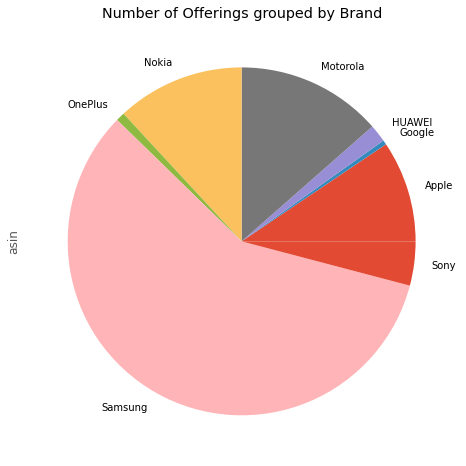

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
# Brand distribution
ax = df.groupby("brand").count()["asin"].plot(kind="pie", 
                                                 figsize=(8, 8),
                                                 title="Number of Offerings grouped by Brand")
plt.show()

In [ ]:
df.groupby('brand').count()['rating'].sort_values(ascending=False)

brand
Samsung     142
Motorola     33
Nokia        29
Apple        23
Sony         10
HUAWEI        4
OnePlus       2
Google        1
Name: rating, dtype: int64

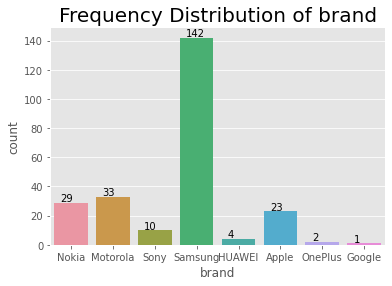

In [ ]:
ax = sns.countplot(data = df, x ='brand')
ax.set_title('Frequency Distribution of brand', fontsize=20)
for p in ax.patches:
        ax.annotate('{:}'.format(p.get_height()), (p.get_x()+0.15, p.get_height()+1))

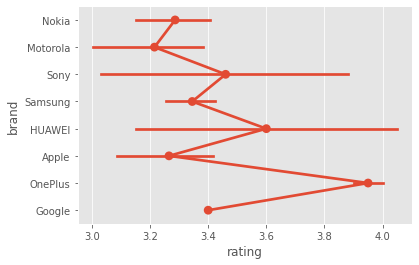

In [ ]:
import seaborn as sns
sns.pointplot(y="brand", x="rating", data=df)

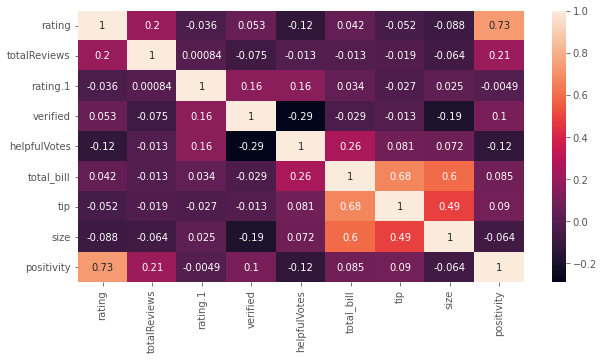

In [ ]:
corelation = df.corr()
corelation

plt.figure(figsize=(10,5))
ax=sns.heatmap(df.corr(),annot=True)

In [ ]:
df.groupby('brand').mean()['rating'].sort_values()

brand
Motorola    3.215152
Apple       3.265217
Nokia       3.286207
Samsung     3.345070
Google      3.400000
Sony        3.460000
HUAWEI      3.600000
OnePlus     3.950000
Name: rating, dtype: float64

In [ ]:
print("The dataset contains {0[0]: ,.0f} rows and {0[1]: .0f} variables.".format(df.shape))


The dataset contains  244 rows and  24 variables.


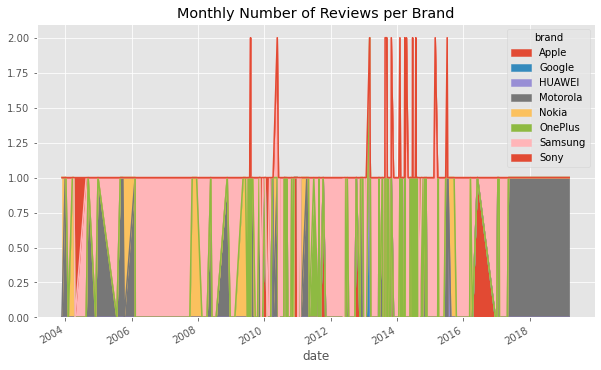

In [ ]:
ax = pd.pivot_table(df, 
                    index="date", 
                    columns="brand", 
                    values="asin", 
                    aggfunc="count", 
                    fill_value=0).plot.area(title="Monthly Number of Reviews per Brand", figsize=(10, 6))

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords
import string
stop = set(stopwords.words('english'))
punc = set(string.punctuation)
keywords = df["brand"].apply(lambda x: x.lower()).unique().tolist()
keywords.append("phone")
lemma = WordNetLemmatizer()
def clean_text(text):
    # Convert the text into lowercase
    text = text.lower()
    # Split into list
    wordList = text.split()
    # Remove punctuation
    wordList = ["".join(x for x in word if (x=="'")|(x not in punc)) for word in wordList]
    # Remove stopwords
    wordList = [word for word in wordList if word not in stop]
    # Remove other keywords
    wordList = [word for word in wordList if word not in keywords]
    # Lemmatisation
    wordList = [lemma.lemmatize(word) for word in wordList]
    return " ".join(wordList)
clean_text("I love phone.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


'love'

In [ ]:
df["subject"] = df["subject"].astype("str")
df["clean_text"] = df["subject"].apply(clean_text)

In [ ]:
df["clean_text"].head().values

array(["a600 awhile absolute doo doo read review detect rage stupid thing finally died used bought garage sale 1 wonder sold cheap bad  hate menu take forever get want scroll endlessly usually phone numbered category u simply press  get want go  pain put silent vibrate class ring turn immediately there's fast way silence damn thing always remember put silent learned hard way  true case mission get break ur nail process also damage case time u try reason started giving problem succeed opening  button could bit bigger vibration could stronger good  reception shabby using elevator remarkable feat considering old would lose service simply putting pocket  compared old work quite well ring tone loud enough hear actually charge quickly great battery life heat like potatoe oven either long convos  nice bright large screen  cute way customize scroll bar set purple pink aqua orange etc overall okay serf purpose definitely pale comparison new phone coming sprint get get great",
       "due softwa

In [ ]:
def word_freq_dict(text):
    # Convert text into word list
    wordList = text.split()
    # Generate word freq dictionary
    wordFreqDict = {word: wordList.count(word) for word in wordList}
    return wordFreqDict
word_freq_dict("I love this phone. I love it.")

{'I': 2, 'it.': 1, 'love': 2, 'phone.': 1, 'this': 1}

In [ ]:
apple = df[df["brand"]=="Apple"].sort_values(by=["date"], ascending=False)
samsung = df[df["brand"]=="Samsung"].sort_values(by=["date"], ascending=False)
xiaomi = df[df["brand"]=="Xiaomi"].sort_values(by=["date"], ascending=False)

In [ ]:
from wordcloud import WordCloud, ImageColorGenerator

# Define a function to create a wordcloud from dictionary of word frequency
def wordcloud_from_frequency(word_freq_dict, title, figure_size=(10, 6)):
    wordcloud.generate_from_frequencies(word_freq_dict)
    plt.figure(figsize=figure_size)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title)
    plt.show()
    
# Define a function to plot top10 positive words and top10 negative words in a grouped bar plot (from dictionaries)
def topn_wordfreq_bar_both(pos_word_freq_dict, neg_word_freq_dict, pos_num_doc, neg_num_doc, topn, title, palette, height=6, aspect=2):
    # Transform positive word frequency into DF
    df_pos = pd.DataFrame.from_dict(pos_word_freq_dict, orient="index").sort_values(by=0, ascending=False).head(topn)
    df_pos.columns = ["frequency"]
    df_pos["frequency"] = df_pos["frequency"] / pos_num_doc
    df_pos["label"] = "Positive"
    # Transform negative word frequency into DF
    df_neg = pd.DataFrame.from_dict(neg_word_freq_dict, orient="index").sort_values(by=0, ascending=False).head(topn)
    df_neg.columns = ["frequency"]
    df_neg["frequency"] = df_neg["frequency"] / neg_num_doc
    df_neg["label"] = "Negative"
    # Append two dataframes
    df_append = df_pos.append(df_neg)
    df_append.reset_index(inplace=True)
    # Plot
    sns.catplot(x="index", y="frequency", hue="label", data=df_append, 
                kind="bar",
                palette=palette,
                height=height, aspect=aspect, 
                legend_out=False)
    plt.title(title)
    plt.show()

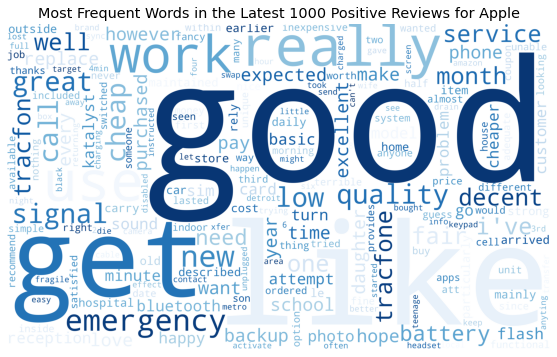

In [ ]:
apple_pos = " ".join(apple[apple["positivity"]==1]["clean_text"][0:1000])
apple_pos_word_freq = word_freq_dict(apple_pos)
wordcloud = WordCloud(width=5000, 
                      height=3000, 
                      max_words=200, 
                      colormap="Blues",
                      background_color="white")
wordcloud_from_frequency(apple_pos_word_freq, "Most Frequent Words in the Latest 1000 Positive Reviews for Apple")

In [ ]:
df["positivity"] = df["rating"].apply(lambda x: 1 if x>3 else(0 if x==3 else -1))

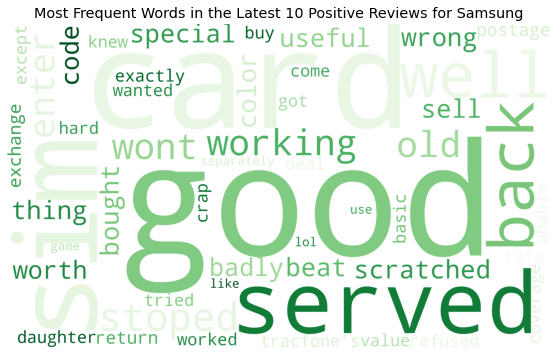

In [ ]:
samsung_pos = " ".join(samsung[samsung["positivity"]==1]["clean_text"][0:10])
samsung_pos_word_freq = word_freq_dict(samsung_pos)
wordcloud = WordCloud(width=5000, 
                      height=3000, 
                      max_words=200, 
                      colormap="Greens",
                      background_color="white")
wordcloud_from_frequency(samsung_pos_word_freq, "Most Frequent Words in the Latest 10 Positive Reviews for Samsung")

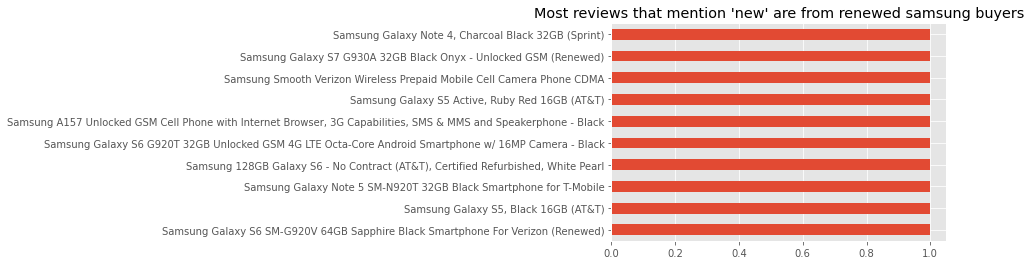

In [ ]:
samsung[samsung["clean_text"].apply(lambda x: "new" in x)]["title"].value_counts().sort_values(ascending=True).tail(10).plot(kind="barh")
plt.title("Most reviews that mention 'new' are from renewed samsung buyers")
plt.show()

In [ ]:
samsung["renewed"] = samsung["title"].apply(lambda x: ("Renewed" in x) | ("Reburshied" in x))
print("{0: 0.1%} samsung that were sold on flipkart are renewed/reburshied.".format(samsung["renewed"].sum() / len(samsung["renewed"])))

 12.0% samsung that were sold on flipkart are renewed/reburshied.


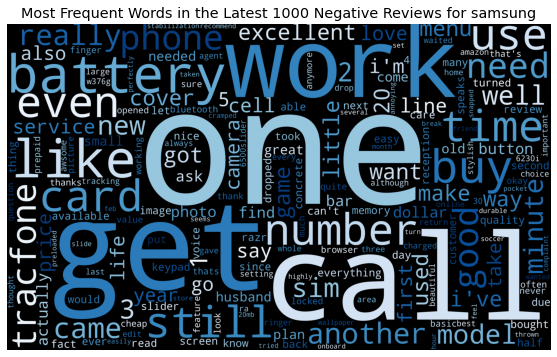

In [ ]:
samsung_neg = " ".join(samsung[samsung["positivity"]==-1]["clean_text"][0:1000])
samsung_neg_word_freq = word_freq_dict(samsung_neg)
wordcloud = WordCloud(width=5000, 
                      height=3000, 
                      max_words=200, 
                      colormap="Blues",
                      background_color="black")
wordcloud_from_frequency(samsung_neg_word_freq, "Most Frequent Words in the Latest 1000 Negative Reviews for samsung")

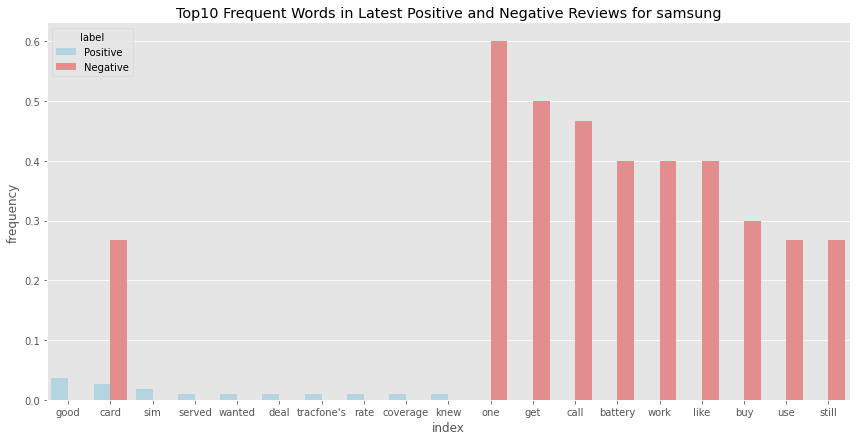

In [ ]:
topn_wordfreq_bar_both(samsung_pos_word_freq, samsung_neg_word_freq, 
                       min(sum(samsung["positivity"]==1), 1000), 
                       min(sum(samsung["positivity"]==-1), 1000), 
                       10, 
                       "Top10 Frequent Words in Latest Positive and Negative Reviews for samsung", 
                       ["lightblue", "lightcoral"], 
                       height=6, aspect=2)

In [ ]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
n_topics=10
lda = LatentDirichletAllocation(n_components=n_topics, 
                                max_iter=50, 
                                learning_method='online',
                                learning_offset=50.,
                                random_state=0)
def print_topn_words(model, feature_names, topn):
    for topic_idx, topic in enumerate(model.components_):
        message = "Topic #%d: " % topic_idx
        message += " ".join([feature_names[i]
                             for i in topic.argsort()[:-topn - 1:-1]])
        print(message)
    print()
tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=0.05, stop_words="english")
t0 = time.time()
samsung_tfidf = tfidf_vectorizer.fit_transform(samsung["clean_text"])
samsung_tfidf_feature_names = tfidf_vectorizer.get_feature_names()
lda.fit(samsung_tfidf)
print("Below is the output from LDA model with {} topics (each includes Top10 words) for Samsung.".format(n_topics))
print_topn_words(lda, samsung_tfidf_feature_names, 10)
print("Done in %0.3fs." % (time.time() - t0))

Below is the output from LDA model with 10 topics (each includes Top10 words) for Samsung.
Topic #0: cell number service time button good got really day new
Topic #1: say nice came great easy number phone love worked quality
Topic #2: great att plan battery life use price tracfone bought love
Topic #3: way good lot work need feature menu minute know tracfone
Topic #4: text ok working month need used bought minute use easy
Topic #5: way really use know minute used purchased fine using amazon
Topic #6: came sim card old like battery buy time really work
Topic #7: better recommend price easy att good feature voice phone use
Topic #8: year best phone use really pocket used battery new cell
Topic #9: wanted little plan good got need buy camera love better

Done in 0.953s.


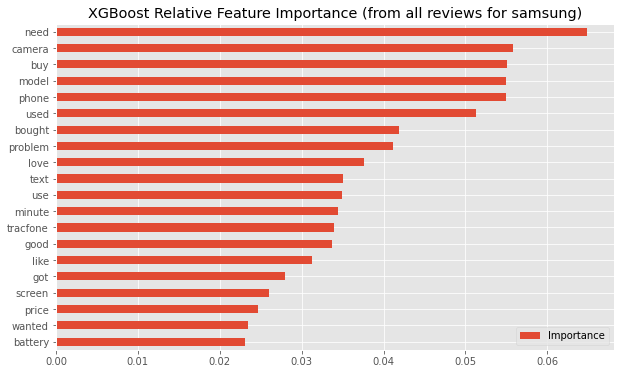

In [ ]:
import xgboost as xgb
xgb_clf = xgb.XGBClassifier()
xgb_clf.fit(samsung_tfidf, samsung["positivity"])
featureImport = pd.DataFrame(xgb_clf.feature_importances_, index=samsung_tfidf_feature_names)
featureImport.columns = ["Importance"]
featureImport.sort_values(["Importance"], ascending=True).tail(20).plot(kind="barh", figsize=(10, 6))
plt.title("XGBoost Relative Feature Importance (from all reviews for samsung)")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
bow_samsung = CountVectorizer(analyzer = clean_text, ngram_range=(1,2)).fit(samsung['clean_text'])
bow_samsung = bow_samsung.transform(samsung['clean_text'])

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf_samsung = TfidfTransformer().fit(bow_samsung)
tfidf_samsung = tfidf_samsung.transform(bow_samsung)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB().fit(tfidf_samsung,samsung['positivity'])
predict = model.predict(tfidf_samsung)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(samsung['positivity'],predict))

              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00        30
         1.0       0.79      1.00      0.88       112

    accuracy                           0.79       142
   macro avg       0.39      0.50      0.44       142
weighted avg       0.62      0.79      0.70       142



In [ ]:
tn, fp, fn, tp = confusion_matrix(samsung['positivity'],predict).ravel()

In [ ]:
from sklearn import svm

clf_svm = svm.SVC(kernel='linear')
clf_svm.fit(tfidf_samsung,samsung['positivity'])
clf_svm.predict(tfidf_samsung)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(samsung['positivity'],predict))

              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00        30
         1.0       0.79      1.00      0.88       112

    accuracy                           0.79       142
   macro avg       0.39      0.50      0.44       142
weighted avg       0.62      0.79      0.70       142



In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(n_estimators=500)
clf_rf.fit(tfidf_samsung,samsung['positivity'])
clf_rf.predict(tfidf_samsung)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(samsung['positivity'],predict))

              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00        30
         1.0       0.79      1.00      0.88       112

    accuracy                           0.79       142
   macro avg       0.39      0.50      0.44       142
weighted avg       0.62      0.79      0.70       142



In [ ]:
X = samsung['clean_text']
y = samsung['positivity']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=101, stratify=y)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier

In [ ]:
pipeline = Pipeline([
    # tokenizing (counting words)
    ('bow',CountVectorizer(analyzer=clean_text)),
    # TF-IDF Scores (pembobotan)
    ('tfidf',TfidfTransformer()),
   
    ('classification', RandomForestClassifier())
])

In [ ]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function clean_text at 0x7f1a597747a0>)),
                ('tfidf', TfidfTransformer()),
                ('classification', RandomForestClassifier())])

In [ ]:
predict = pipeline.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

        -1.0       0.67      0.25      0.36         8
         1.0       0.82      0.96      0.89        28

    accuracy                           0.81        36
   macro avg       0.74      0.61      0.62        36
weighted avg       0.78      0.81      0.77        36



In [ ]:
pred_proba = pipeline.predict_proba(X_test)
pred_proba 

array([[0.09, 0.91],
       [0.11, 0.89],
       [0.28, 0.72],
       [0.45, 0.55],
       [0.12, 0.88],
       [0.2 , 0.8 ],
       [0.34, 0.66],
       [0.15, 0.85],
       [0.11, 0.89],
       [0.31, 0.69],
       [0.3 , 0.7 ],
       [0.16, 0.84],
       [0.11, 0.89],
       [0.24, 0.76],
       [0.21, 0.79],
       [0.5 , 0.5 ],
       [0.2 , 0.8 ],
       [0.18, 0.82],
       [0.07, 0.93],
       [0.15, 0.85],
       [0.58, 0.42],
       [0.16, 0.84],
       [0.14, 0.86],
       [0.63, 0.37],
       [0.34, 0.66],
       [0.14, 0.86],
       [0.31, 0.69],
       [0.07, 0.93],
       [0.43, 0.57],
       [0.34, 0.66],
       [0.12, 0.88],
       [0.08, 0.92],
       [0.14, 0.86],
       [0.1 , 0.9 ],
       [0.12, 0.88],
       [0.33, 0.67]])

In [ ]:
predict = [ 1 if prob > 0.60 else -1 for prob in pred_proba[:,1]]
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

        -1.0       0.40      0.25      0.31         8
         1.0       0.81      0.89      0.85        28

    accuracy                           0.75        36
   macro avg       0.60      0.57      0.58        36
weighted avg       0.72      0.75      0.73        36



In [ ]:
len(stopwords.words('english'))

179

In [ ]:
!pip install langdetect
from langdetect import detect
def lang_detect(text):
    try:
               return detect(text)
    except:
         return None
import time
start_time = time.time()
df["lang"] = df["subject"].apply(lang_detect)
print("It takes %s seconds for the code to finish." % (time.time() - start_time))

     |████████████████████████████████| 981 kB 8.1 MB/s 
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993242 sha256=8991abe95c0cc6ab62e70a3bc9ccd92d7d54c333840e1fec5b917f80195ea6c5
  Stored in directory: /root/.cache/pip/wheels/c5/96/8a/f90c59ed25d75e50a8c10a1b1c2d4c402e4dacfa87f3aff36a
Successfully built langdetect
It takes 2.209080457687378 seconds for the code to finish.


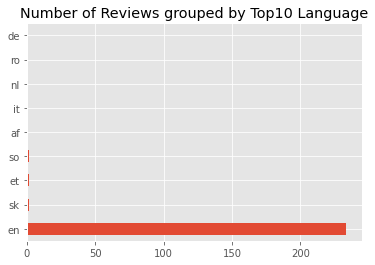

In [ ]:
df["lang"].value_counts()[:10].plot(kind="barh", title="Number of Reviews grouped by Top10 Language")
plt.show()

In [ ]:
df = df[df["lang"]=="en"]

In [ ]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
analyzer.polarity_scores("mobile looks great.")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


{'compound': 0.6249, 'neg': 0.0, 'neu': 0.328, 'pos': 0.672}

In [ ]:
start_time = time.time()
df["subject"] = df["subject"].astype("str")
df["sent_neg"] = df["subject"].apply(lambda x: analyzer.polarity_scores(x)["neg"])
df["sent_neu"] = df["subject"].apply(lambda x: analyzer.polarity_scores(x)["neu"])
df["sent_pos"] = df["subject"].apply(lambda x: analyzer.polarity_scores(x)["pos"])
df["sent_comp"] = df["subject"].apply(lambda x: analyzer.polarity_scores(x)["compound"])
print("It takes %s seconds for the code to finish." % (time.time() - start_time))

It takes 1.0941002368927002 seconds for the code to finish.


In [ ]:
 df.to_csv("df_with_sentiment_scores.csv")

In [ ]:
df_en = pd.read_csv("/content/df_with_sentiment_scores.csv")

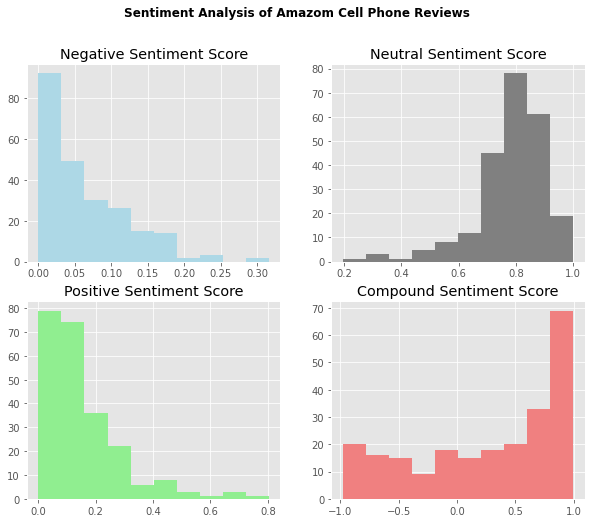

In [ ]:
plt.figure()

plt.subplot(2, 2, 1)
df_en["sent_neg"].hist(figsize=(10, 8), color="lightblue")
plt.title("Negative Sentiment Score")
plt.subplot(2, 2, 2)
df_en["sent_neu"].hist(figsize=(10, 8), color="grey")
plt.title("Neutral Sentiment Score")
plt.subplot(2, 2, 3)
df_en["sent_pos"].hist(figsize=(10, 8), color="lightgreen")
plt.title("Positive Sentiment Score")
plt.subplot(2, 2, 4)
df_en["sent_comp"].hist(figsize=(10, 8), color="lightcoral")
plt.title("Compound Sentiment Score")

plt.suptitle('Sentiment Analysis of Amazom Cell Phone Reviews', fontsize=12, fontweight='bold');

plt.show()

The correlation coefficient between sentiment score (compound) and rating is -0.0273 with a p-value of  0.6789.


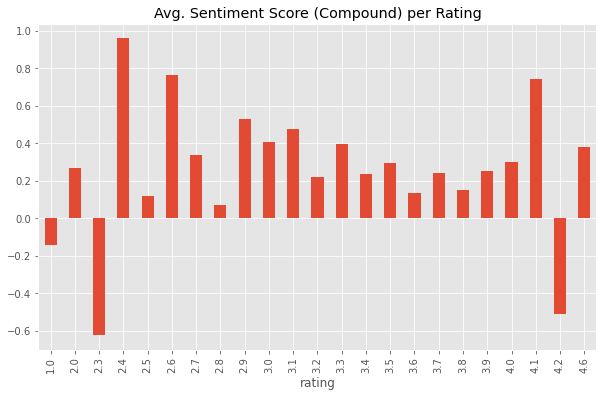

In [ ]:
import numpy as np
import scipy.stats as stats
print("The correlation coefficient between sentiment score (compound) and rating is {0[0]: .4f} with a p-value of {0[1]: .4f}.".format(stats.pearsonr(df_en["rating"], df_en["sent_comp"])))
df_en.groupby("rating").mean()["sent_comp"].plot(kind="bar", figsize=(10, 6))
plt.title("Avg. Sentiment Score (Compound) per Rating")
plt.show()

The correlation coefficient between sentiment score (compound) and rating is  0.0241 with a p-value of  0.7147.


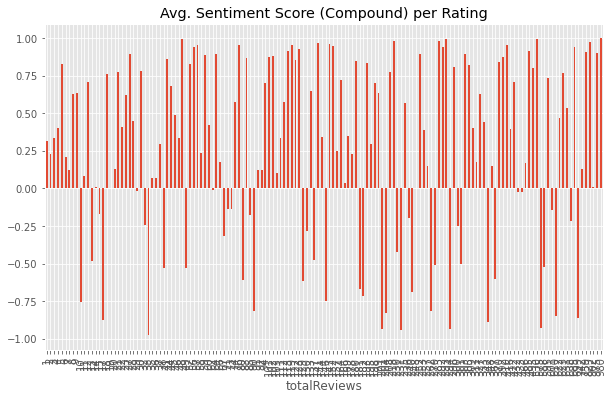

In [ ]:
import numpy as np
import scipy.stats as stats
print("The correlation coefficient between sentiment score (compound) and rating is {0[0]: .4f} with a p-value of {0[1]: .4f}.".format(stats.pearsonr(df_en["totalReviews"], df_en["sent_comp"])))
df_en.groupby("totalReviews").mean()["sent_comp"].plot(kind="bar", figsize=(10, 6))
plt.title("Avg. Sentiment Score (Compound) per Rating")
plt.show()